In [134]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib
import pickle


In [248]:
# FILENAME = 'scan_data_1780588864.6213105.pkl' # straight driving, straight cars
# FILENAME = 'scan_data_1785124269.3392477.pkl' # wobbly driving, angled cars
# FILENAME = 'scan_data_1785124440.5982285.pkl' # straight driving, angled cars
# FILENAME = 'scan_data_1785130340.2872536.pkl' # straight driving, straight cars, wall
# FILENAME = 'scan_data_1785130557.9081867.pkl' # wobbly driving, angled cars, wall
# FILENAME = 'scan_data_1785130814.8221273.pkl' # straight driving, straight cars, wall, 4 actor
# FILENAME = 'scan_data_1785165166.777948.pkl' # angled driving, straight cars, wall, 4 actor
FILENAME = 'scan_data_1785167024.0177522.pkl' # more angled driving, straight cars, wall, 4 actor

data = {}
with open('../data/' + FILENAME, 'rb') as f:
    data = pickle.load(f)


In [249]:
print(np.array(data['scans']['scans'][0]))
print(data['scans']['metadata'])


[30.005959 30.009066 30.002035 ... 29.992804 29.972809 30.000154]
{'angle_min': -2.3499999046325684, 'angle_max': 2.3499999046325684, 'angle_increment': 0.004351851996034384, 'range_min': 0.0, 'range_max': 30.0}


In [250]:
def get_obstacle_patch(obb: OrientedBoundingBox, color='blue', alpha=0.6, linewidth=2):
        
    lower_left_x = obb.centroid_x_m - (obb.length_m / 2)
    lower_left_y = obb.centroid_y_m + (obb.width_m / 2)
    
    edgecolor, facecolor = '', ''
    if color == 'blue':
        edgecolor = 'blue'
        facecolor = 'lightblue'
    elif color == 'darkblue':
        edgecolor = 'darkblue'
        facecolor = 'blue'
    elif color == 'orange':
        edgecolor = 'red'
        facecolor = 'orange'
    elif color == 'red':
        edgecolor = 'darkred'
        facecolor = 'red'
    elif color == 'black':
        edgecolor = 'black'
        facecolor = 'grey'
    elif color == 'green':
        edgecolor = 'darkgreen'
        facecolor = 'green'
    
    rect = matplotlib.patches.Rectangle(
        xy=(-lower_left_y, lower_left_x),
        width=obb.width_m,
        height=obb.length_m,
        angle=np.degrees(obb.heading_rad),
        rotation_point='center',  # Instructs matplotlib to rotate around the center
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        linewidth=linewidth
    )
    return rect

def cartesian_to_xy(scan, scan_metadata, max_dist=29.9):
    
    num_points = len(scan)
    xy_points = np.zeros((num_points, 2))
    
    curr_angle = scan_metadata['angle_min']
    angle_increment = scan_metadata['angle_increment']
    
    # print(scan)
    
    for idx, distance in enumerate(scan):
        
        x, y = np.inf, np.inf
        # print(distance)
        if distance <= max_dist:
            x = distance * np.cos(curr_angle)
            y = distance * np.sin(curr_angle)
        
        xy_points[idx, :] = [x, y]
        
        curr_angle += angle_increment
        
    return xy_points
        
def batch_process_point_clouds(scans, scan_metadata):
    
    num_scans = len(scans)
    num_points = len(scans[0])
    
    parsed_scans = np.zeros((num_scans, num_points, 2))
    
    for idx, scan in enumerate(scans):
        parsed_scans[idx, :, :] = cartesian_to_xy(scan, scan_metadata)

    return parsed_scans


In [251]:
# parsed_scans = batch_process_point_clouds(data['scans']['scans'], data['scans']['metadata'])


In [261]:
from scipy.interpolate import interp1d
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import time
import math
# from cv2 import minAreaRect

def get_rot_mat(theta_rad):
    return np.array([
        [np.cos(theta_rad), np.sin(theta_rad)],
        [-np.sin(theta_rad), np.cos(theta_rad)]
    ])

class OrientedBoundingBox:
    
    def __init__(self, centroid_x_m, centroid_y_m, length_m, width_m, heading_rad):
        self.centroid_x_m = centroid_x_m
        self.centroid_y_m = centroid_y_m
        self.length_m = length_m
        self.width_m = width_m
        self.heading_rad = heading_rad
        self.corners = self.get_corners()
        
    def get_corners(self):
        rot_mat = get_rot_mat(self.heading_rad)
        min_x, max_x = - (self.length_m / 2), (self.length_m / 2)
        min_y, max_y = - (self.width_m / 2), (self.width_m / 2)
        local_corners = np.array([[min_x, min_y],[min_x, max_y],[max_x, min_y],[max_x, max_y]])
        transformed_corners = np.dot(local_corners, rot_mat)
        transformed_corners[:,0] += self.centroid_x_m
        transformed_corners[:,1] += self.centroid_y_m
        return transformed_corners
    
    def __repr__(self):
        return f'OBB(x = {self.centroid_x_m:.3f}, y = {self.centroid_y_m:.3f}, l = {self.length_m:.3f}, w = {self.width_m:.3f}, theta = {self.heading_rad:.3f})'

class OccupancyGrid2D:
    
    def __init__(self, point_cloud, grid_size_m=0.05):
        
        self.point_cloud = point_cloud
        self.grid_size_m = grid_size_m
        
        # initialize occupancy grid array
        self.grid, self.x_idx_offset, self.y_idx_offset = self.initialize_grid(grid_size_m=grid_size_m)
        
        # fill grid with points
        self.fill_grid()

    def initialize_grid(self, grid_size_m=0.05):
        
        x_min, x_max = np.min(self.point_cloud[:, 0]), np.max(self.point_cloud[:, 0])
        y_min, y_max = np.min(self.point_cloud[:, 1]), np.max(self.point_cloud[:, 1])
        
        num_x_buckets = int(x_max // grid_size_m) - int(x_min // grid_size_m) + 1
        num_y_buckets = int(y_max // grid_size_m) - int(y_min // grid_size_m) + 1
        
        x_idx_offset = -1 * int(x_min // grid_size_m)
        y_idx_offset = -1 * int(y_min // grid_size_m)
        
        return np.zeros((num_x_buckets, num_y_buckets)), x_idx_offset, y_idx_offset
    
    def fill_grid(self):
        
        for point in self.point_cloud:
            x_idx = int(point[0] // self.grid_size_m) + self.x_idx_offset
            y_idx = int(point[1] // self.grid_size_m) + self.y_idx_offset
            self.grid[x_idx, y_idx] += 1
            
    def get_spaces_with_at_least_n_points(self, min_points):
        
        filtered_point_cloud = []
        
        for x_idx in range(self.grid.shape[0]):
            for y_idx in range(self.grid.shape[1]):
                if self.grid[x_idx][y_idx] >= min_points:
                    x_mean = (x_idx - self.x_idx_offset + 0.5) * self.grid_size_m
                    y_mean = (y_idx - self.y_idx_offset + 0.5) * self.grid_size_m
                    filtered_point_cloud.append([x_mean, y_mean])
                    
        return np.array(filtered_point_cloud)

class SlamManager:
        
    def __init__(self, scan_data, odom_data, ego_length=0.8, ego_width=0.48, mask=None):
        
        start_time = time.perf_counter()
        
        self.ego_length = ego_length
        self.ego_width = ego_width
        
        self.lat_clearance = 0.03
        self.long_clearance = 0.04
        
        self.scan_data = scan_data
        self.odom_data = odom_data
        
        self.scan_metadata = self.scan_data['metadata']
        if mask is None:
            self.scans = self.scan_data['scans']
            self.scan_times = self.scan_data['times']
        else:
            self.scans = np.array(self.scan_data['scans'])[mask]
            self.scan_times = np.array(self.scan_data['times'])[mask]
            
        self.pose_array = np.array(self.odom_data['poses'])
        self.initial_ego_pose = self.pose_array[0,:] # [x, y, theta]
        
        # create linear interpolators for time to pose functions
        self.time_to_global_x = interp1d(self.odom_data['times'], self.pose_array[:,0], fill_value="extrapolate")
        self.time_to_global_y = interp1d(self.odom_data['times'], self.pose_array[:,1], fill_value="extrapolate")
        self.time_to_global_theta = interp1d(self.odom_data['times'], self.pose_array[:,2], fill_value="extrapolate")
        
        self.time_to_local_x = lambda time, x: x + (self.time_to_global_x(time) - self.initial_ego_pose[0])
        self.time_to_local_y = lambda time, y: y + (self.time_to_global_y(time) - self.initial_ego_pose[1])
        self.time_to_local_theta = lambda time, theta: theta + (self.time_to_global_theta(time) - self.initial_ego_pose[2])
        
        print(f"Setup time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
    def ego_to_world(self, time_s, points):
        
        x_ego = self.time_to_global_x(time_s) - self.initial_ego_pose[0]
        y_ego = self.time_to_global_y(time_s) - self.initial_ego_pose[1]
        theta_ego = self.time_to_global_theta(time_s) - self.initial_ego_pose[2]
        
        world_vec = np.dot(np.array([x_ego, y_ego]), get_rot_mat(-self.initial_ego_pose[2]))
        
        transformed_points = np.dot(points, get_rot_mat(theta_ego)) + world_vec
        return transformed_points
        
    def run_perception_pipeline(self):
        
        first_start_time = time.perf_counter()
        start_time = time.perf_counter()
        
        # do all the lidar preprocessing here
        self.parsed_scans = self.batch_process_point_clouds()
        print(f"Batch proc time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.aligned_point_clouds = self.align_point_clouds()
        print(f"Align time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.filtered_point_cloud = self.filter_finite_points(self.aligned_point_clouds)
        print(f"Filter time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.downsampled_point_cloud = self.downsample_point_cloud(self.filtered_point_cloud)
        print(f"Downsample time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        # cluster aligned point clouds
        self.cluster_idxs = self.cluster_points(self.downsampled_point_cloud)
        print(f"Cluster time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        # extract bounding boxes from individual clusters
        self.bounding_boxes = self.extract_obbs(self.downsampled_point_cloud, self.cluster_idxs)
        print(f"OBB extraction time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.parking_regions = self.get_parking_regions(self.bounding_boxes)
        print(f"Parking region extraction time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        print(f'=========== PIPELINE DONE: {time.perf_counter() - first_start_time:.6f} SECONDS ============')
        
        return self.bounding_boxes, self.parking_regions
    
    def cartesian_to_xy(self, scan, scan_metadata, max_dist=29.9):
    
        num_points = len(scan)
        xy_points = np.zeros((num_points, 2))
        
        curr_angle = scan_metadata['angle_min']
        angle_increment = scan_metadata['angle_increment']
        
        # print(scan)
    
        for idx, distance in enumerate(scan):
            
            x, y = np.inf, np.inf
            # print(distance)
            if distance <= max_dist:
                x = distance * np.cos(curr_angle)
                y = distance * np.sin(curr_angle)
            
            xy_points[idx, :] = [x, y]
            
            curr_angle += angle_increment
            
            return xy_points
        
    def batch_process_point_clouds(self):
        
        # print(len(self.scans))
        num_scans = len(self.scans)
        num_points = len(self.scans[0])
        
        parsed_scans = np.zeros((num_scans, num_points, 2))
        
        for idx, scan in enumerate(self.scans):
            parsed_scans[idx, :, :] = cartesian_to_xy(scan, self.scan_metadata)

        return parsed_scans
    
    def align_point_clouds(self):
        
        num_scans = len(self.parsed_scans)
        num_points = len(self.parsed_scans[0])
        
        aligned_point_clouds = np.zeros((num_scans * num_points, 2))
        
        for scan_idx, scan in enumerate(self.parsed_scans):
            scan_time = self.scan_times[scan_idx]
            transformed_points = self.ego_to_world(scan_time, scan)
            
            lower_idx = scan_idx * num_points
            upper_idx = (scan_idx + 1) * num_points
            aligned_point_clouds[lower_idx:upper_idx, 0] = transformed_points[:,0]
            aligned_point_clouds[lower_idx:upper_idx, 1] = transformed_points[:,1]
            
        return aligned_point_clouds
    
    def filter_finite_points(self, point_cloud):
        mask = np.isfinite(point_cloud)
        filtered_point_cloud = point_cloud[mask].reshape(-1, 2)
        return filtered_point_cloud
    
    def downsample_point_cloud(self, point_cloud, grid_size_m=0.02, min_samples=3):
        
        grid = OccupancyGrid2D(point_cloud, grid_size_m)
        return grid.get_spaces_with_at_least_n_points(min_samples)
    
    def cluster_points(self, point_cloud, min_cluster_size=5):
        
        clustering = HDBSCAN(min_cluster_size=min_cluster_size).fit(point_cloud)
        return clustering.labels_
        
    def extract_obbs(self, point_cloud, cluster_idxs):
        
        bboxes = []        
        num_clusters = np.max(cluster_idxs) + 1
        
        for idx in range(num_clusters):
            cluster_points = point_cloud[cluster_idxs == idx]
            # bbox = self.obb_from_cluster_points(cluster_points)
            bbox = self.obb_from_cluster_points_rotating_calipers(cluster_points)
            bboxes.append(bbox)
            
        return bboxes
    
    def get_min_bounding_box(self, points, angle_rad):
        
        center = np.mean(points, axis=0)
        centered_points = points - center
        rot_mat = get_rot_mat(angle_rad)
        rotated_points = np.dot(centered_points, rot_mat)
        min_x, max_x = np.min(rotated_points[:,0]), np.max(rotated_points[:,0])
        min_y, max_y = np.min(rotated_points[:,1]), np.max(rotated_points[:,1])
        obb_center = center + np.dot(np.array([min_x + max_x, min_y + max_y]) / 2.0, rot_mat.T)
        
        # get centroid, length, width, angle of obb
        bbox_centroid_x, bbox_centroid_y = obb_center[0], obb_center[1]
        bbox_length = max_x - min_x
        bbox_width = max_y - min_y
        bbox_angle_rad = angle_rad
        
        bbox = OrientedBoundingBox(bbox_centroid_x, bbox_centroid_y, bbox_length, bbox_width, -bbox_angle_rad)
        
        return bbox
    
    def points_vec_dist(self, points, vec_p1, vec_p2):
        """Computes minimum distance from points to a bounded line segment (p1 -> p2)."""
        v = vec_p2 - vec_p1
        v_sq = np.dot(v, v)
        if v_sq == 0:
            return np.linalg.norm(points - vec_p1, axis=1)

        # Vector from p1 to all points
        ap = points - vec_p1  # Shape: (N, 2)

        # Scalar projection parameter t
        t = np.dot(ap, v) / v_sq  # Shape: (N,)

        # CRITICAL FIX: Clamp t to [0, 1] to stay on the physical segment
        t_clamped = np.clip(t, 0.0, 1.0)

        # Closest point on the segment
        closest = vec_p1 + t_clamped[:, np.newaxis] * v  # Shape: (N, 2)

        return np.linalg.norm(points - closest, axis=1)

    def get_min_dist_from_points_to_edges(self, obb, points):
        vec1_dists = self.points_vec_dist(points, obb.corners[0], obb.corners[1])
        vec2_dists = self.points_vec_dist(points, obb.corners[1], obb.corners[3])
        vec3_dists = self.points_vec_dist(points, obb.corners[0], obb.corners[2])
        vec4_dists = self.points_vec_dist(points, obb.corners[3], obb.corners[2])
        return np.min([vec1_dists, vec2_dists, vec3_dists, vec4_dists], axis=0)
        
    def obb_from_cluster_points_rotating_calipers(self, cluster_points):
        
        # get the convex hull of the cluster
        # hull = ConvexHull(cluster_points)
        
        # go through all the edges of the hull and get the angles of each one
        # hull_edge_angles = set([])
        # for simplex in hull.simplices:
        #     point1 = cluster_points[simplex[0]]
        #     point2 = cluster_points[simplex[1]]
        #     hull_edge_angles.add(round(np.arctan2(point2[1] - point1[1], point2[0] - point1[0]), 4))
        
        hull_edge_angles = np.arange(math.pi/4, 3*math.pi/4, 0.02)
        
        min_mean_min_dist, best_obb = float('inf'), None
        # min_area, best_obb = float('inf'), None
        for angle_rad in hull_edge_angles:
            obb = self.get_min_bounding_box(cluster_points, angle_rad)
            mean_min_dist = np.mean(np.square(self.get_min_dist_from_points_to_edges(obb, cluster_points)))
            # print(angle_rad, mean_min_dist)
            # area = obb.length_m * obb.width_m
            if mean_min_dist < min_mean_min_dist:
            # if area < min_area:
                min_mean_min_dist = mean_min_dist
                # min_area = area
                best_obb = obb
                
        return best_obb
    
    def get_parking_space_between_obbs(self, obb1, obb2):
        
        # get angle of the parking space
        mean_angle = (obb1.heading_rad + obb2.heading_rad) / 2
        
        # axis-align bounding boxes
        rot_mat = get_rot_mat(-mean_angle)
        aligned_obb_1_corners = np.dot(obb1.corners, rot_mat)
        aligned_obb_2_corners = np.dot(obb2.corners, rot_mat)
        
        # get longitudinal clearance
        max_x = max(np.max(aligned_obb_1_corners[:,0]), np.max(aligned_obb_2_corners[:,0]))
        min_x = min(np.min(aligned_obb_1_corners[:,0]), np.min(aligned_obb_2_corners[:,0]))
        total_long_clearance = abs(max_x - min_x) + (2.0 * self.long_clearance)
        
        # x centroid is just the average of the min and max x
        x_centroid = (min_x + max_x) / 2
        
        # get minimum y separation between the two boxes
        min_y_1, max_y_1 = np.min(aligned_obb_1_corners[:,1]), np.max(aligned_obb_1_corners[:,1])
        min_y_2, max_y_2 = np.min(aligned_obb_2_corners[:,1]), np.max(aligned_obb_2_corners[:,1])
        
        # get min lateral separation (need to figure out which pair of edges are closest together)
        lateral_seps = np.array([abs(min_y_1 - max_y_2), abs(max_y_1 - min_y_2)])
        edge_pairs = [
            np.array([ [[min_x, min_y_1], [max_x, min_y_1]],   [[min_x, max_y_2], [max_x, max_y_2]] ]),
            np.array([ [[min_x, max_y_1], [max_x, max_y_1]],   [[min_x, min_y_2], [max_x, min_y_2]] ])
        ]
        min_idx = np.argmin(lateral_seps)
        min_lat_sep = lateral_seps[min_idx]
        min_edge_pair = edge_pairs[min_idx]
        total_lat_clearance = min_lat_sep - (2.0 * self.lat_clearance)
        
        # figure out where y centroid should be based on mean of min edge pair
        y_centroid = (min_edge_pair[0,0,1] + min_edge_pair[1,0,1]) / 2
        
        # transform centroid back into rotated space
        transformed_centroid = np.dot(np.array([x_centroid, y_centroid]), rot_mat.T)
        
        parking_space = OrientedBoundingBox(
            transformed_centroid[0],
            transformed_centroid[1],
            total_long_clearance,
            total_lat_clearance,
            mean_angle
        )
        
        print(parking_space)
        
        return parking_space

    def get_parking_regions(self, obbs):
        
        parking_regions = []
        
        # divide obbs between left and right
        left_obbs = [obb for obb in obbs if obb.centroid_y_m > 0]
        right_obbs = [obb for obb in obbs if obb.centroid_y_m < 0]
        
        # sort each side by longitudinal distance
        sorted_left_obbs = sorted(left_obbs, key = lambda obb: obb.centroid_x_m)
        sorted_right_obbs = sorted(right_obbs, key = lambda obb: obb.centroid_x_m)
        
        # get distances between left obbs, add to available parking spaces if sufficient clearance
        for idx in range(len(sorted_left_obbs) - 1):
            parking_region = self.get_parking_space_between_obbs(sorted_left_obbs[idx], sorted_left_obbs[idx+1])
            if parking_region.width_m > self.ego_width:
                parking_regions.append(parking_region)
            
        # get distances between right obbs
        for idx in range(len(sorted_right_obbs) - 1):
            parking_region = self.get_parking_space_between_obbs(sorted_right_obbs[idx], sorted_right_obbs[idx+1])
            if parking_region.width_m > self.ego_width:
                parking_regions.append(parking_region)
                
        return parking_regions


In [262]:
# make a mask to only take every tenth scan (current rate is 250Hz / 100 = 2.5Hz)
mask = np.array([i % 25 == 0 for i in range(len(data['scans']['scans']))])
s = SlamManager(data['scans'], data['poses'], mask=mask)
bboxes, parking_regions = s.run_perception_pipeline()


Setup time: 0.008539 seconds
Batch proc time: 0.293237 seconds
Align time: 0.006252 seconds
Filter time: 0.000232 seconds
Downsample time: 0.047007 seconds
Cluster time: 0.006720 seconds
OBB extraction time: 0.053169 seconds
OBB(x = 0.136, y = -0.976, l = 0.867, w = 0.138, theta = -1.905)
OBB(x = 1.082, y = -1.334, l = 0.890, w = 0.789, theta = -1.915)
OBB(x = 2.030, y = -1.681, l = 0.877, w = 0.131, theta = -1.915)
Parking region extraction time: 0.000164 seconds
=========== PIPELINE DONE: 0.407185 SECONDS ============


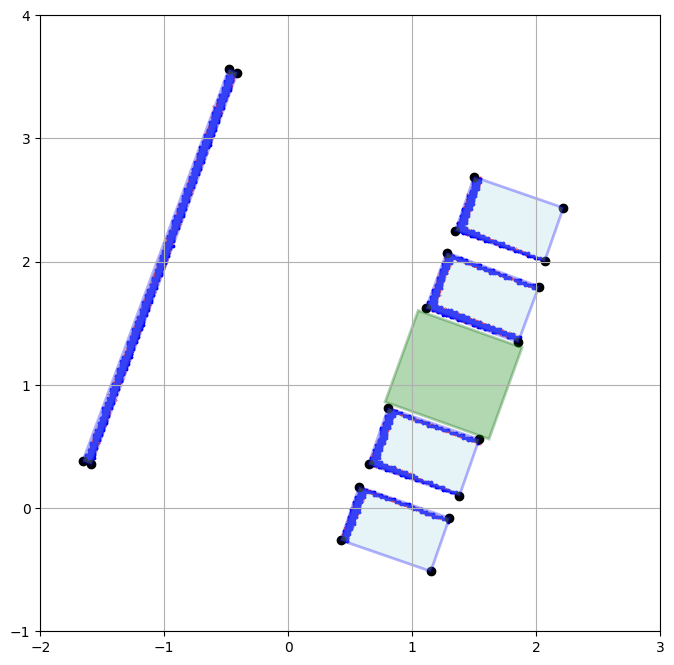

In [264]:
plt.scatter(-s.aligned_point_clouds[:,1], s.aligned_point_clouds[:,0], s=0.1, c='red')
plt.scatter(-s.downsampled_point_cloud[:,1], s.downsampled_point_cloud[:,0], s=3.0, c='blue')

for b in bboxes:
    rect = get_obstacle_patch(b, alpha=0.3)
    plt.scatter(-b.corners[:,1], b.corners[:,0], c='black')
    plt.gca().add_patch(rect)

for r in parking_regions:
    rect = get_obstacle_patch(r, alpha=0.3, color='green')
    plt.gca().add_patch(rect)

plt.xlim(-2, 3)
plt.ylim(-1, 4)
plt.gcf().set_size_inches(8, 8)
plt.grid()

# obb1 = OrientedBoundingBox(-0.420, -1.363, 1.192, -0.049, -1.735)
# obb2 = OrientedBoundingBox(0.569, -1.533, 1.450, 0.447, -1.745)
# obb3 = OrientedBoundingBox(1.562, -1.688, 1.195, -0.040, -1.735)
# plt.scatter(-obb1.centroid_y_m, obb1.centroid_x_m, c='green', s=10.0)
# plt.scatter(-obb2.centroid_y_m, obb2.centroid_x_m, c='green', s=10.0)
# plt.scatter(-obb3.centroid_y_m, obb3.centroid_x_m, c='green', s=10.0)


[-1.9253981633974493, -1.9053981633974493, -1.9053981633974493, -1.9253981633974493, -1.9053981633974493]
[OBB(x = 1.082, y = -1.334, l = 0.890, w = 0.789, theta = -1.915)]


IndexError: index 1200 is out of bounds for axis 0 with size 100

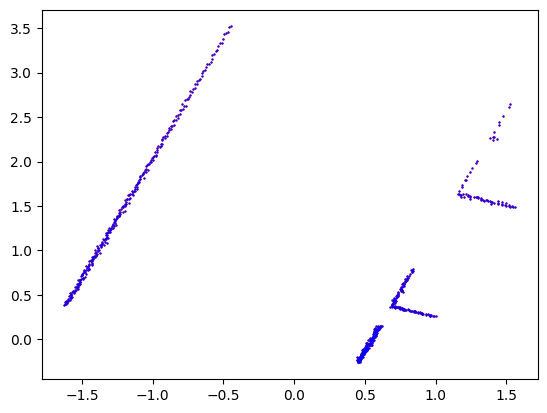

In [265]:
print([b.heading_rad for b in bboxes])
print(parking_regions)
s.parsed_scans.shape
idx = 1000

for idx in [0, 1200]:
    scan_time = s.scan_times[idx]
    transformed_points = s.ego_to_world(scan_time, s.parsed_scans[idx])
    plt.scatter(-s.parsed_scans[idx,:,1], s.parsed_scans[idx,:,0], s=0.3, c='red')
    plt.scatter(-transformed_points[:,1], transformed_points[:,0], s=0.3, c='blue')

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()


0.8498525596797226


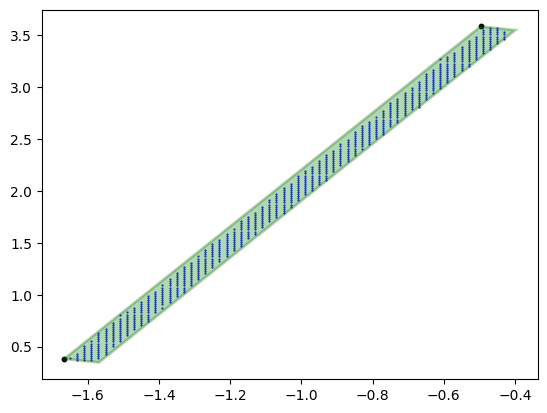

In [91]:
cluster_points = s.downsampled_point_cloud[s.cluster_idxs == 0]
plt.scatter(-cluster_points[:,1], cluster_points[:,0], s=0.3, c='blue')
# plt.xlim(0, 2)
# plt.ylim(-1, 1)

# angle = 1.58
angle = 0.35
obb = s.get_min_bounding_box(cluster_points, angle)

vec1_dists = s.points_vec_dist(cluster_points, obb.corners[0], obb.corners[1])
vec2_dists = s.points_vec_dist(cluster_points, obb.corners[1], obb.corners[3])
vec3_dists = s.points_vec_dist(cluster_points, obb.corners[0], obb.corners[2])
vec4_dists = s.points_vec_dist(cluster_points, obb.corners[3], obb.corners[2])

vec_idx_1 = 3
vec_idx_2 = 1
plt.scatter(-obb.corners[vec_idx_1,1], obb.corners[vec_idx_1,0], s=10.0, c='black')
plt.scatter(-obb.corners[vec_idx_2,1], obb.corners[vec_idx_2,0], s=10.0, c='black')

# print(vec1_dists)

mean_min_dist = np.mean(s.get_min_dist_from_points_to_edges(obb, cluster_points))

rect = get_obstacle_patch(obb, alpha=0.3, color='green')
plt.gca().add_patch(rect)
print(mean_min_dist)


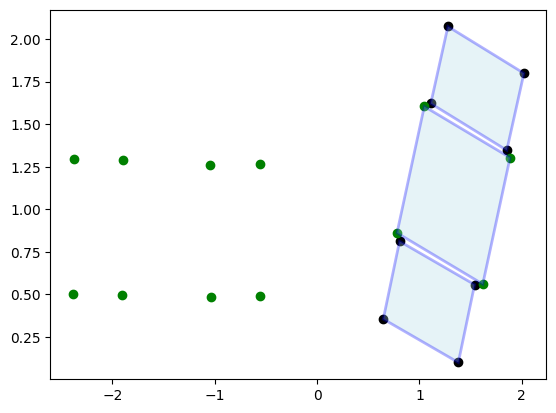

In [ ]:
obb1 = bboxes[2]
obb2 = bboxes[3]

for b in [obb1, obb2]:
    rect = get_obstacle_patch(b, alpha=0.3)
    plt.scatter(-b.corners[:,1], b.corners[:,0], c='black')
    plt.gca().add_patch(rect)

# get angle of the parking space
mean_angle = (obb1.heading_rad + obb2.heading_rad) / 2

# axis-align bounding boxes
rot_mat = get_rot_mat(-mean_angle)
aligned_obb_1_corners = np.dot(obb1.corners, rot_mat)
aligned_obb_2_corners = np.dot(obb2.corners, rot_mat)

plt.scatter(-aligned_obb_1_corners[:,1], aligned_obb_1_corners[:,0], c='green')
plt.scatter(-aligned_obb_2_corners[:,1], aligned_obb_2_corners[:,0], c='green')

# get longitudinal clearance
max_x = max(np.max(aligned_obb_1_corners[:,0]), np.max(aligned_obb_2_corners[:,0]))
min_x = min(np.min(aligned_obb_1_corners[:,0]), np.min(aligned_obb_2_corners[:,0]))
total_long_clearance = abs(max_x - min_x) + (2.0 * s.long_clearance)

# x centroid is just the average of the min and max x
x_centroid = (min_x + max_x) / 2

# get minimum y separation between the two boxes
min_y_1, max_y_1 = np.min(aligned_obb_1_corners[:,1]), np.max(aligned_obb_1_corners[:,1])
min_y_2, max_y_2 = np.min(aligned_obb_2_corners[:,1]), np.max(aligned_obb_2_corners[:,1])

# get min lateral separation (need to figure out which pair of edges are closest together)
lateral_seps = np.array([abs(min_y_1 - max_y_2), abs(max_y_1 - min_y_2)])
edge_pairs = [
    np.array([ [[min_x, min_y_1], [max_x, min_y_1]],   [[min_x, max_y_2], [max_x, max_y_2]] ]),
    np.array([ [[min_x, max_y_1], [max_x, max_y_1]],   [[min_x, min_y_2], [max_x, min_y_2]] ])
]
min_idx = np.argmin(lateral_seps)
min_lat_sep = lateral_seps[min_idx]
min_edge_pair = edge_pairs[min_idx]
total_lat_clearance = min_lat_sep - (2.0 * s.lat_clearance)

# figure out where y centroid should be based on mean of min edge pair
y_centroid = (min_edge_pair[0,0,1] + min_edge_pair[1,0,1]) / 2

# transform centroid back into rotated space
transformed_centroid = np.dot(np.array([x_centroid, y_centroid]), rot_mat.T)

parking_space = OrientedBoundingBox(
    transformed_centroid[0],
    transformed_centroid[1],
    total_long_clearance,
    total_lat_clearance,
    mean_angle
)

for b in [parking_space]:
    rect = get_obstacle_patch(b, alpha=0.3)
    plt.scatter(-b.corners[:,1], b.corners[:,0], c='green')
    plt.gca().add_patch(rect)
